>RiskProof AI: Random Forest Baseline on Fraud Oracle

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import joblib

_ = (pd, np, plt, sns, RandomForestClassifier, train_test_split, GridSearchCV, StandardScaler, accuracy_score, confusion_matrix, classification_report, pickle, joblib)

## 1. Load Dataset

In [6]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [7]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('\nMissing values before:\n', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:\n', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0
Duplicates after: 0

Missing values before:
 0
Missing values after:
 0
Cleaned shape: (15420, 33)


## 3. Feature Engineering and Split

In [8]:
X_raw = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

categorical_cols = X_raw.select_dtypes(include=['object', 'string']).columns
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print('Features shape after encoding:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Features shape after encoding: (15420, 124)
Train shape: (12336, 124)
Test shape: (3084, 124)


## 4. Train Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best parameters found: {best_params}')
print(f'Best cross-validation accuracy: {best_score:.4f}')

# Evaluate on the test set
final_preds = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, final_preds)
print(f'Test set accuracy with best model: {test_accuracy:.4f}')

print('\nSample predictions from best model:', final_preds[:10])

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.9407
Test set accuracy with best model: 0.9403

Sample predictions from best model: [0 0 0 0 0 0 0 0 0 0]


## 5. Evaluate and Visualize

Final model accuracy: 0.940337224383917

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084

Confusion matrix:
 [[2899    0]
 [ 184    1]]


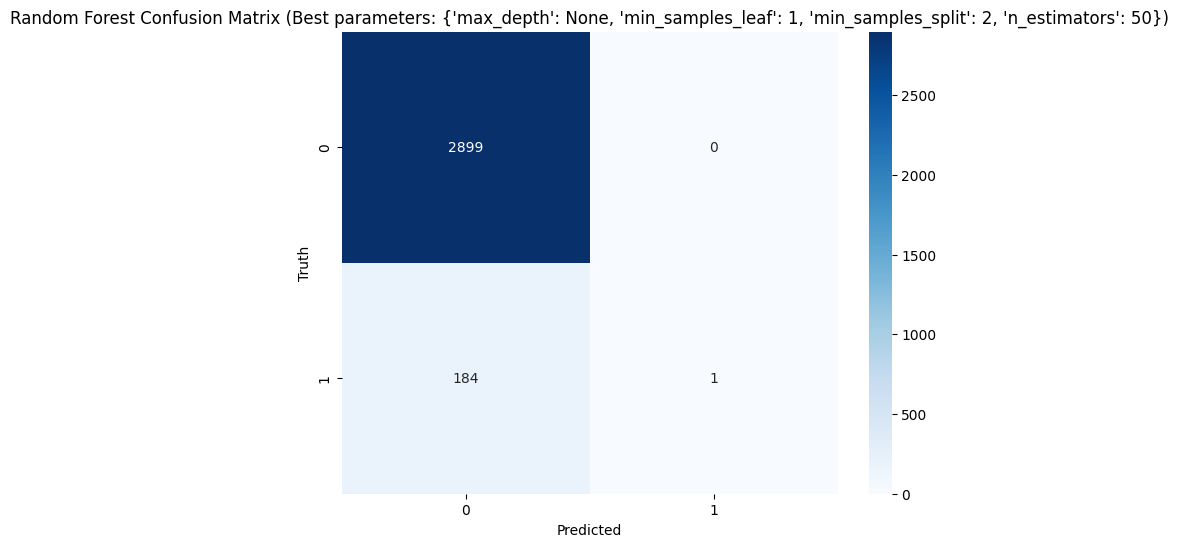

Sample risk scores: [ 2.  6.  2. 10.  0.  4.  0. 24.  4.  0.]
Sample risk labels: ['Low-risk incident' 'Low-risk incident' 'Low-risk incident'
 'Low-risk incident' 'Low-risk incident' 'Low-risk incident'
 'Low-risk incident' 'Low-risk incident' 'Low-risk incident'
 'Low-risk incident']
Saved model files: riskproof_random_forest.pkl and riskproof_random_forest.joblib


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import joblib

final_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, final_preds)

print('Final model accuracy:', accuracy_score(y_test, final_preds))
print('\nClassification report:\n', classification_report(y_test, final_preds, zero_division=0))
print('Confusion matrix:\n', cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title(f'Random Forest Confusion Matrix (Best parameters: {best_params})')
plt.show()

if hasattr(best_model, 'predict_proba'):
    fraud_probabilities = best_model.predict_proba(X_test)[:, 1]
    risk_scores = fraud_probabilities * 100
    risk_labels = np.where(risk_scores >= 50, 'High-risk incident', 'Low-risk incident')
    print('Sample risk scores:', np.round(risk_scores[:10], 2))
    print('Sample risk labels:', risk_labels[:10])

with open('riskproof_random_forest.pkl', 'wb') as f:
    pickle.dump(best_model, f)

joblib.dump(best_model, 'riskproof_random_forest.joblib')
print('Saved model files: riskproof_random_forest.pkl and riskproof_random_forest.joblib')